In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv(r"C:\Users\E\Downloads\archive (2).zip")

# EDA

In [9]:
df.head()

,timestamp,road_segment_id,avg_speed_kmph,density_veh_per_km,avg_wait_time_s,occupancy_pct,flow_veh_per_hr,queue_length_veh,avg_accel_ms2,heading_deg,...,avg_comm_delay_ms,rssi_dbm,packet_loss_pct,speed_density_ratio,congestion_pressure,wireless_congestion_intensity,throughput_per_queued_vehicle,acceleration_directionality,weather_factor,label
0,2025-09-29T04:54:49,S090,43.38,24.78,20.57,39.85,1463.49,7.36,0.488,181.26,...,51.66,-60.28,5.56,1.7504,5.0977,1.6645,198.7510,88.4849,156.3778,Moderate
1,2025-09-30T06:15:38,S339,4.50,89.61,120.69,95.67,105.16,55.69,-1.047,0.78,...,204.45,-69.48,30.34,0.0502,108.1477,26.7853,1.8885,-0.8207,20.1982,Gridlock
2,2025-09-29T05:46:06,S167,45.68,29.45,17.79,42.26,1536.62,11.43,0.462,184.61,...,49.53,-58.90,4.60,1.5510,5.2396,1.3304,134.4387,85.2133,150.1454,Moderate
3,2025-09-28T21:15:29,S030,44.34,30.17,27.13,34.66,1486.33,9.63,0.550,174.62,...,49.64,-60.43,5.30,1.4700,8.1846,1.6631,154.2838,96.0502,149.7671,Moderate
4,2025-09-28T00:29:20,S261,66.86,5.30,7.86,12.45,1954.74,1.75,0.757,88.26,...,21.00,-55.23,0.30,12.6102,0.4169,0.0236,1117.7505,66.8219,259.8905,Free-flow


In [10]:
df.shape

(195714, 27)

In [11]:
df.columns

Index(['timestamp', 'road_segment_id', 'avg_speed_kmph', 'density_veh_per_km',
       'avg_wait_time_s', 'occupancy_pct', 'flow_veh_per_hr',
       'queue_length_veh', 'avg_accel_ms2', 'heading_deg', 'signal_state_num',
       'incident_num', 'temp_c', 'visibility_km', 'rain_intensity_mmph',
       'channel_busy_ratio_pct', 'msg_rate_hz', 'avg_comm_delay_ms',
       'rssi_dbm', 'packet_loss_pct', 'speed_density_ratio',
       'congestion_pressure', 'wireless_congestion_intensity',
       'throughput_per_queued_vehicle', 'acceleration_directionality',
       'weather_factor', 'label'],
      dtype='str')

In [12]:
df.dtypes

timestamp                            str
road_segment_id                      str
avg_speed_kmph                   float64
density_veh_per_km               float64
avg_wait_time_s                  float64
occupancy_pct                    float64
flow_veh_per_hr                  float64
queue_length_veh                 float64
avg_accel_ms2                    float64
heading_deg                      float64
signal_state_num                 float64
incident_num                     float64
temp_c                           float64
visibility_km                    float64
rain_intensity_mmph              float64
channel_busy_ratio_pct           float64
msg_rate_hz                      float64
avg_comm_delay_ms                float64
rssi_dbm                         float64
packet_loss_pct                  float64
speed_density_ratio              float64
congestion_pressure              float64
wireless_congestion_intensity    float64
throughput_per_queued_vehicle    float64
acceleration_dir

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 195714 entries, 0 to 195713
Data columns (total 27 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   timestamp                      195714 non-null  str    
 1   road_segment_id                195714 non-null  str    
 2   avg_speed_kmph                 195714 non-null  float64
 3   density_veh_per_km             195714 non-null  float64
 4   avg_wait_time_s                195714 non-null  float64
 5   occupancy_pct                  195714 non-null  float64
 6   flow_veh_per_hr                195714 non-null  float64
 7   queue_length_veh               195714 non-null  float64
 8   avg_accel_ms2                  195714 non-null  float64
 9   heading_deg                    195714 non-null  float64
 10  signal_state_num               195714 non-null  float64
 11  incident_num                   195714 non-null  float64
 12  temp_c                         195714 non

In [14]:
df.describe()

,avg_speed_kmph,density_veh_per_km,avg_wait_time_s,occupancy_pct,flow_veh_per_hr,queue_length_veh,avg_accel_ms2,heading_deg,signal_state_num,incident_num,...,msg_rate_hz,avg_comm_delay_ms,rssi_dbm,packet_loss_pct,speed_density_ratio,congestion_pressure,wireless_congestion_intensity,throughput_per_queued_vehicle,acceleration_directionality,weather_factor
count,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,...,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000,195714.000000
mean,40.113615,42.531785,41.490966,48.635799,1217.380428,20.595787,0.087940,141.391571,2.318778,0.752956,...,16.590649,81.221076,-61.594159,10.756338,2.703669,29.231785,7.649460,479.399182,21.554183,151.111290
std,23.680900,29.323898,41.245668,31.320898,693.234355,20.800210,0.664306,94.558893,1.090006,0.702711,...,5.498945,64.104660,5.500902,10.716784,3.200042,39.484254,9.924541,1316.049020,65.401348,96.690242
min,1.030000,1.100000,-2.630000,1.390000,41.120000,-1.270000,-1.360000,-16.880000,0.754000,-0.209000,...,6.590000,14.060000,-73.170000,0.160000,0.011100,-0.291000,0.012300,0.626000,-167.467600,12.078400
25%,23.740000,12.010000,7.020000,12.020000,777.080000,2.800000,-0.351000,86.830000,1.060000,0.051000,...,10.800000,21.490000,-65.510000,0.580000,0.392100,0.726600,0.061000,30.063400,-6.825700,71.214650
50%,43.710000,31.910000,21.935000,41.640000,1474.340000,11.030000,0.348000,173.770000,2.039000,0.532000,...,15.510000,51.620000,-60.520000,5.520000,1.400700,6.668150,1.671050,135.860450,59.731750,154.236700
75%,68.010000,61.940000,52.570000,71.590000,1959.920000,26.400000,0.721000,187.480000,3.038000,1.032000,...,20.510000,101.920000,-55.810000,15.770000,5.818675,31.782400,9.516500,712.129100,73.527975,266.234175
max,77.970000,101.200000,137.870000,103.490000,2153.180000,72.990000,1.153000,286.750000,4.270000,2.206000,...,28.350000,214.570000,-51.490000,36.140000,66.406900,127.390100,33.106500,21384.541400,130.857400,338.956700


In [15]:
df.columns.tolist()

['timestamp',
 'road_segment_id',
 'avg_speed_kmph',
 'density_veh_per_km',
 'avg_wait_time_s',
 'occupancy_pct',
 'flow_veh_per_hr',
 'queue_length_veh',
 'avg_accel_ms2',
 'heading_deg',
 'signal_state_num',
 'incident_num',
 'temp_c',
 'visibility_km',
 'rain_intensity_mmph',
 'channel_busy_ratio_pct',
 'msg_rate_hz',
 'avg_comm_delay_ms',
 'rssi_dbm',
 'packet_loss_pct',
 'speed_density_ratio',
 'congestion_pressure',
 'wireless_congestion_intensity',
 'throughput_per_queued_vehicle',
 'acceleration_directionality',
 'weather_factor',
 'label']

In [16]:
df.isnull().sum()

timestamp                        0
road_segment_id                  0
avg_speed_kmph                   0
density_veh_per_km               0
avg_wait_time_s                  0
occupancy_pct                    0
flow_veh_per_hr                  0
queue_length_veh                 0
avg_accel_ms2                    0
heading_deg                      0
signal_state_num                 0
incident_num                     0
temp_c                           0
visibility_km                    0
rain_intensity_mmph              0
channel_busy_ratio_pct           0
msg_rate_hz                      0
avg_comm_delay_ms                0
rssi_dbm                         0
packet_loss_pct                  0
speed_density_ratio              0
congestion_pressure              0
wireless_congestion_intensity    0
throughput_per_queued_vehicle    0
acceleration_directionality      0
weather_factor                   0
label                            0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.shape

(195714, 27)

In [19]:
TARGET ="congestion_pressure"

In [20]:
print(df[TARGET].value_counts())

congestion_pressure
0.4257      23
0.4438      21
0.4862      21
0.4916      21
0.3725      20
            ..
4.8090       1
32.5014      1
98.2762      1
34.9938      1
107.5470     1
Name: count, Length: 111898, dtype: int64


In [21]:
df.head()

,timestamp,road_segment_id,avg_speed_kmph,density_veh_per_km,avg_wait_time_s,occupancy_pct,flow_veh_per_hr,queue_length_veh,avg_accel_ms2,heading_deg,...,avg_comm_delay_ms,rssi_dbm,packet_loss_pct,speed_density_ratio,congestion_pressure,wireless_congestion_intensity,throughput_per_queued_vehicle,acceleration_directionality,weather_factor,label
0,2025-09-29T04:54:49,S090,43.38,24.78,20.57,39.85,1463.49,7.36,0.488,181.26,...,51.66,-60.28,5.56,1.7504,5.0977,1.6645,198.7510,88.4849,156.3778,Moderate
1,2025-09-30T06:15:38,S339,4.50,89.61,120.69,95.67,105.16,55.69,-1.047,0.78,...,204.45,-69.48,30.34,0.0502,108.1477,26.7853,1.8885,-0.8207,20.1982,Gridlock
2,2025-09-29T05:46:06,S167,45.68,29.45,17.79,42.26,1536.62,11.43,0.462,184.61,...,49.53,-58.90,4.60,1.5510,5.2396,1.3304,134.4387,85.2133,150.1454,Moderate
3,2025-09-28T21:15:29,S030,44.34,30.17,27.13,34.66,1486.33,9.63,0.550,174.62,...,49.64,-60.43,5.30,1.4700,8.1846,1.6631,154.2838,96.0502,149.7671,Moderate
4,2025-09-28T00:29:20,S261,66.86,5.30,7.86,12.45,1954.74,1.75,0.757,88.26,...,21.00,-55.23,0.30,12.6102,0.4169,0.0236,1117.7505,66.8219,259.8905,Free-flow


In [22]:
df.columns

Index(['timestamp', 'road_segment_id', 'avg_speed_kmph', 'density_veh_per_km',
       'avg_wait_time_s', 'occupancy_pct', 'flow_veh_per_hr',
       'queue_length_veh', 'avg_accel_ms2', 'heading_deg', 'signal_state_num',
       'incident_num', 'temp_c', 'visibility_km', 'rain_intensity_mmph',
       'channel_busy_ratio_pct', 'msg_rate_hz', 'avg_comm_delay_ms',
       'rssi_dbm', 'packet_loss_pct', 'speed_density_ratio',
       'congestion_pressure', 'wireless_congestion_intensity',
       'throughput_per_queued_vehicle', 'acceleration_directionality',
       'weather_factor', 'label'],
      dtype='str')

In [23]:
df.dtypes

timestamp                            str
road_segment_id                      str
avg_speed_kmph                   float64
density_veh_per_km               float64
avg_wait_time_s                  float64
occupancy_pct                    float64
flow_veh_per_hr                  float64
queue_length_veh                 float64
avg_accel_ms2                    float64
heading_deg                      float64
signal_state_num                 float64
incident_num                     float64
temp_c                           float64
visibility_km                    float64
rain_intensity_mmph              float64
channel_busy_ratio_pct           float64
msg_rate_hz                      float64
avg_comm_delay_ms                float64
rssi_dbm                         float64
packet_loss_pct                  float64
speed_density_ratio              float64
congestion_pressure              float64
wireless_congestion_intensity    float64
throughput_per_queued_vehicle    float64
acceleration_dir

# Visualization


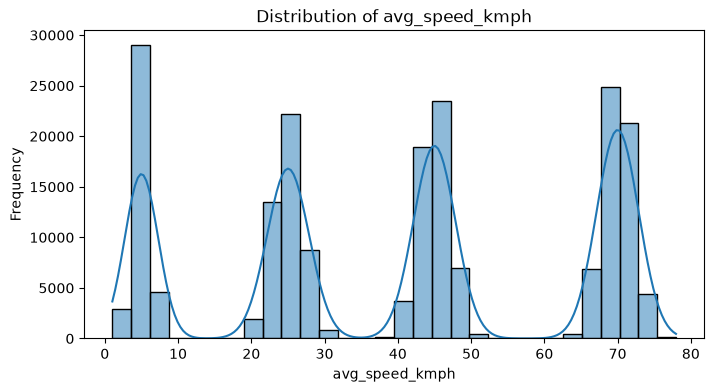

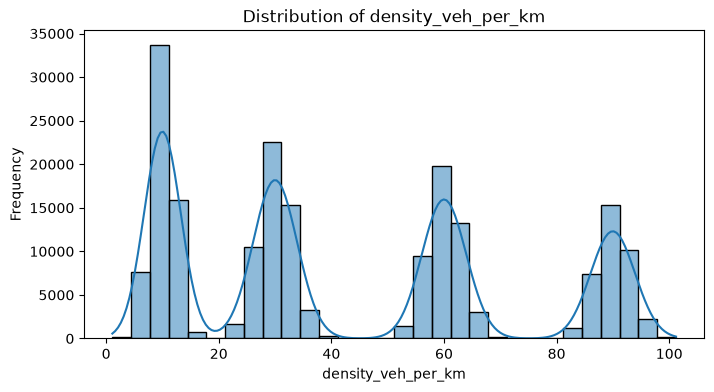

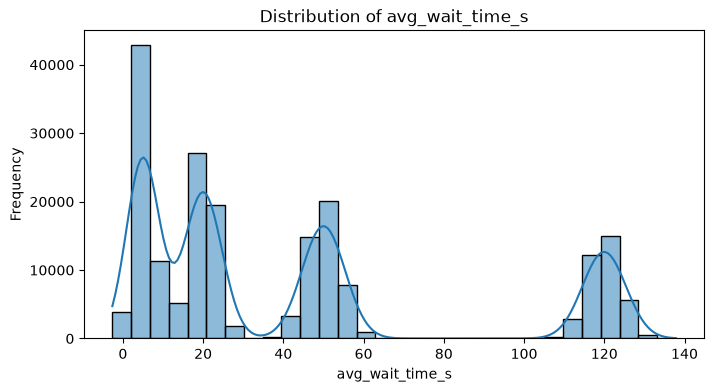

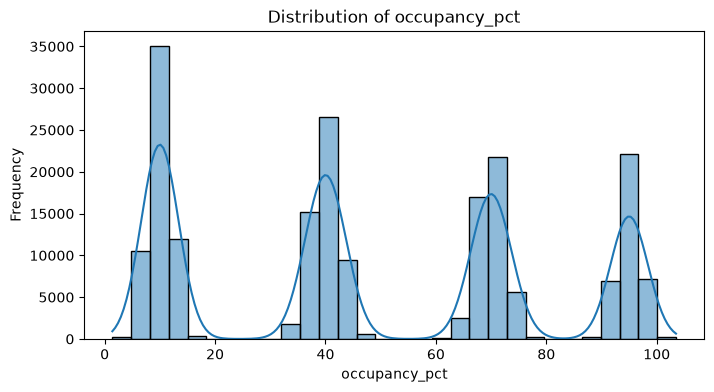

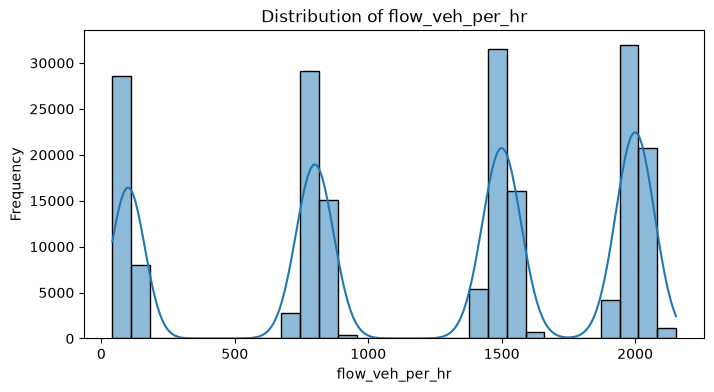

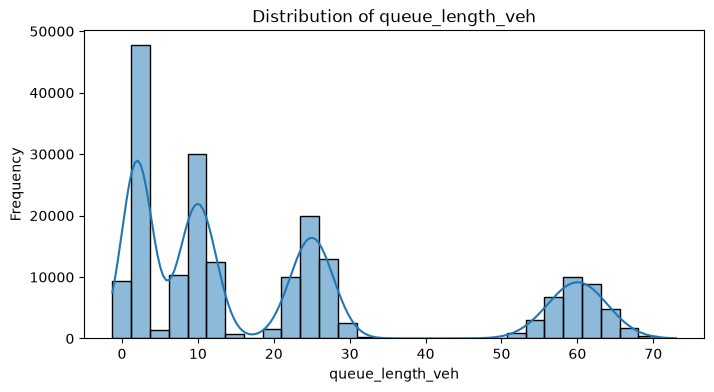

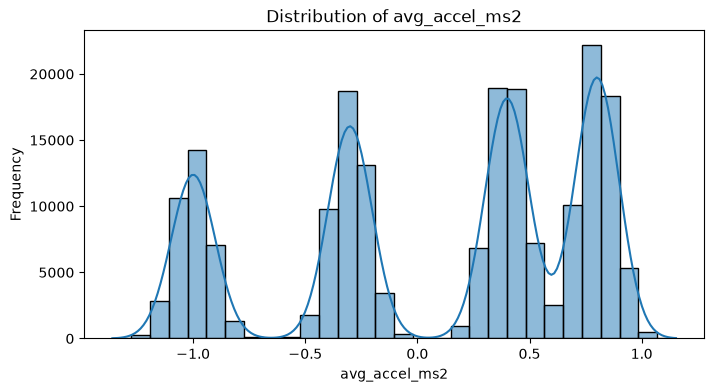

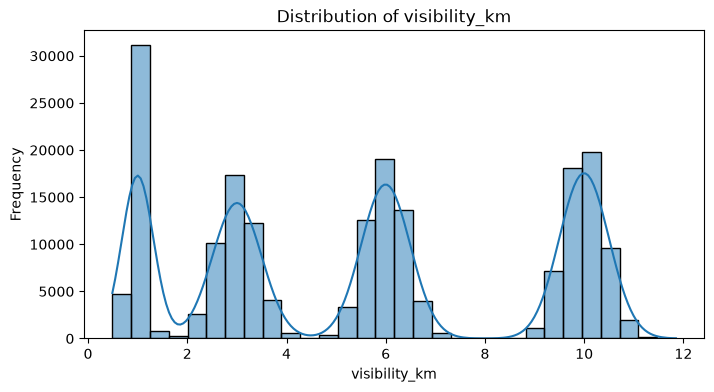

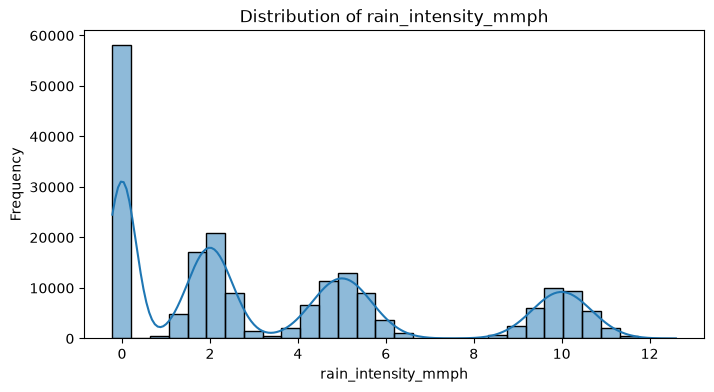

In [24]:
#Plot Distribution
features_to_plot = [
    'avg_speed_kmph',
    'density_veh_per_km',
    'avg_wait_time_s',
    'occupancy_pct',
    'flow_veh_per_hr',
    'queue_length_veh',
    'avg_accel_ms2',
    'visibility_km',
    'rain_intensity_mmph'
]

for col in features_to_plot:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

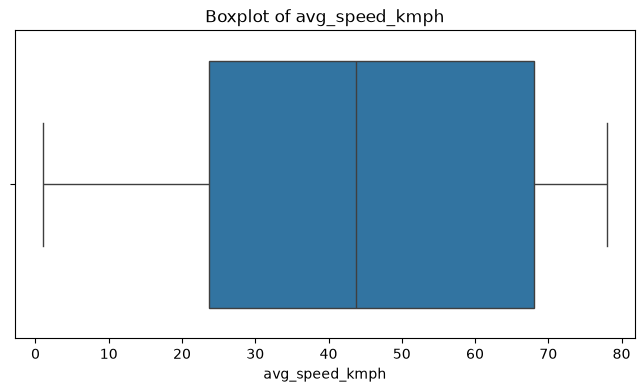

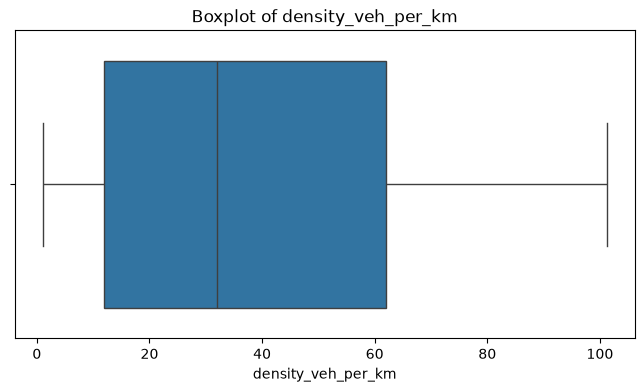

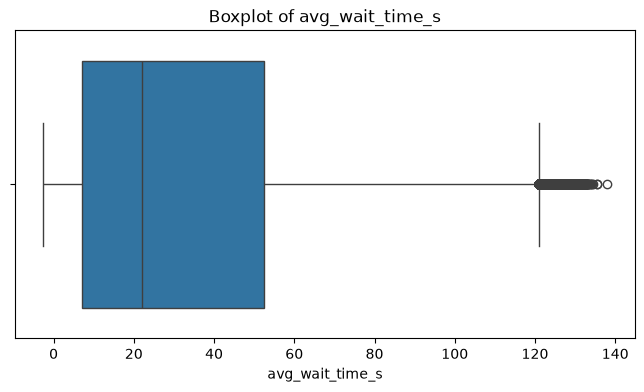

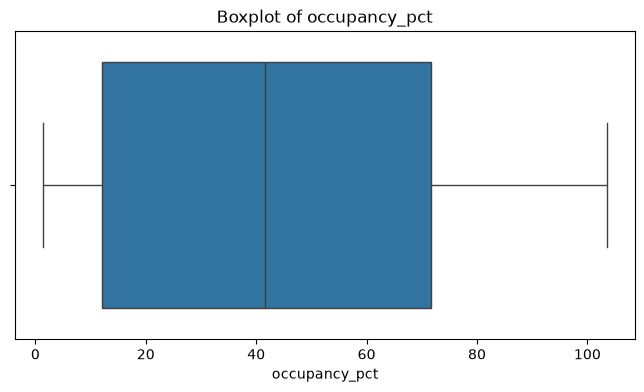

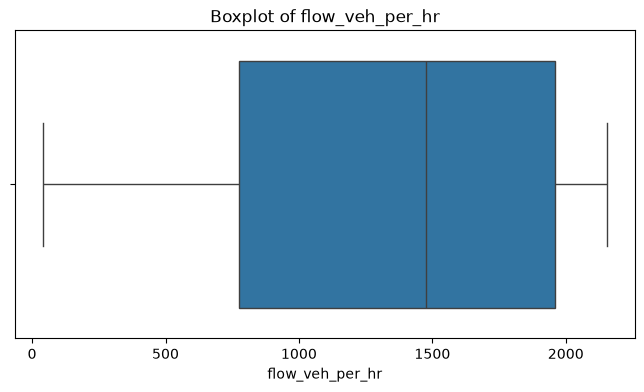

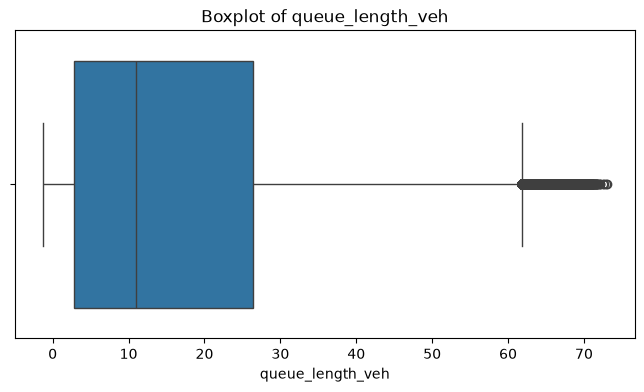

In [25]:
# Outliers
features_to_check = [
    'avg_speed_kmph',
    'density_veh_per_km',
    'avg_wait_time_s',
    'occupancy_pct',
    'flow_veh_per_hr',
    'queue_length_veh'
]

for col in features_to_check:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


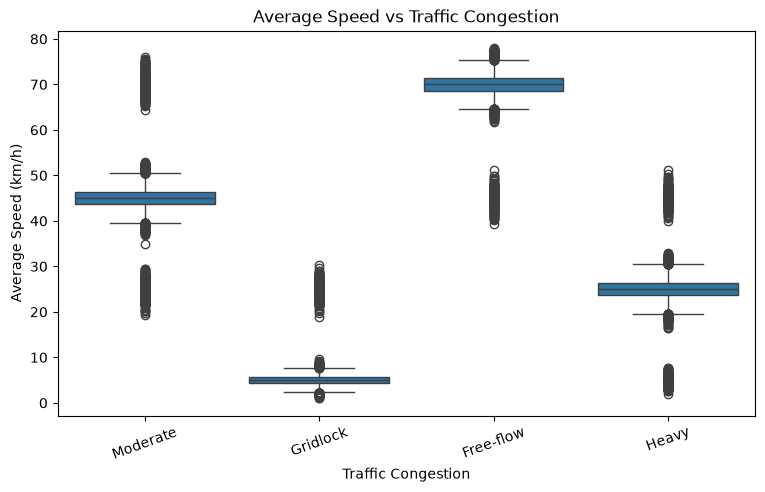

In [26]:
# Analyze congestion vs average speed
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='label',
    y='avg_speed_kmph'
)

plt.title("Average Speed vs Traffic Congestion")
plt.xlabel("Traffic Congestion")
plt.ylabel("Average Speed (km/h)")
plt.xticks(rotation=20)

plt.show()

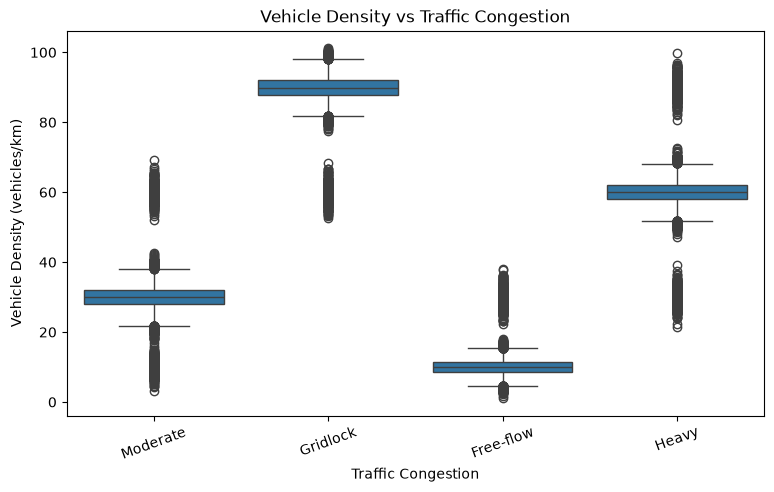

In [27]:
# Congestion vs Vehicle Density
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='label',
    y='density_veh_per_km'
)

plt.title("Vehicle Density vs Traffic Congestion")
plt.xlabel("Traffic Congestion")
plt.ylabel("Vehicle Density (vehicles/km)")
plt.xticks(rotation=20)

plt.show()

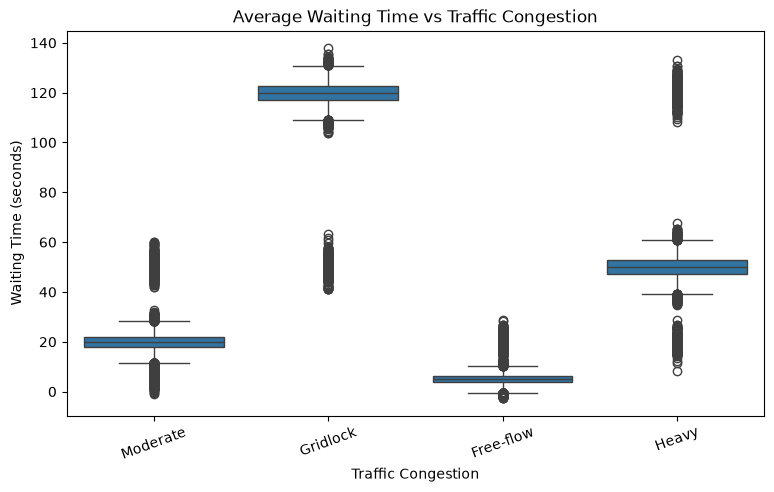

In [28]:
# Congestion vs Waiting Time
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='label',
    y='avg_wait_time_s'
)

plt.title("Average Waiting Time vs Traffic Congestion")
plt.xlabel("Traffic Congestion")
plt.ylabel("Waiting Time (seconds)")
plt.xticks(rotation=20)

plt.show()

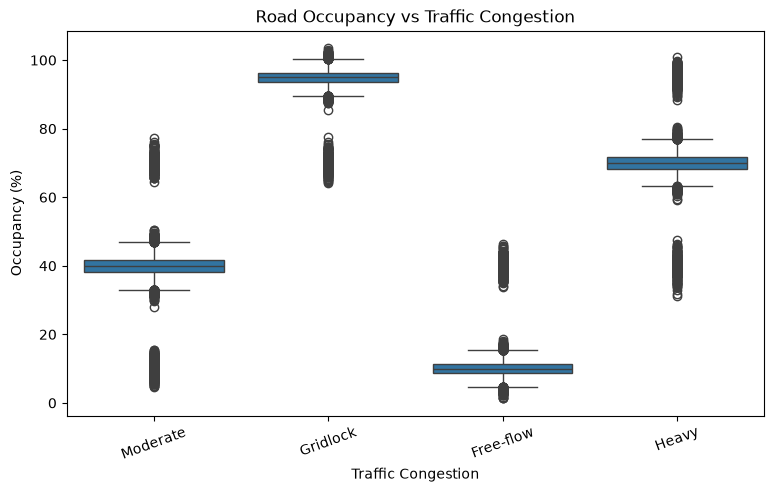

In [29]:
# Congestion vs Occupancy
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='label',
    y='occupancy_pct'
)

plt.title("Road Occupancy vs Traffic Congestion")
plt.xlabel("Traffic Congestion")
plt.ylabel("Occupancy (%)")
plt.xticks(rotation=20)

plt.show()

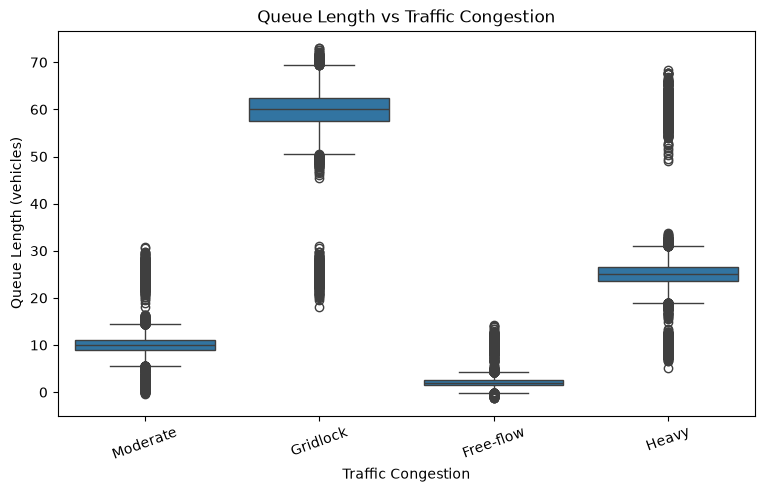

In [30]:
# Congestion vs Queue Length
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x='label',
    y='queue_length_veh'
)

plt.title("Queue Length vs Traffic Congestion")
plt.xlabel("Traffic Congestion")
plt.ylabel("Queue Length (vehicles)")
plt.xticks(rotation=20)

plt.show()


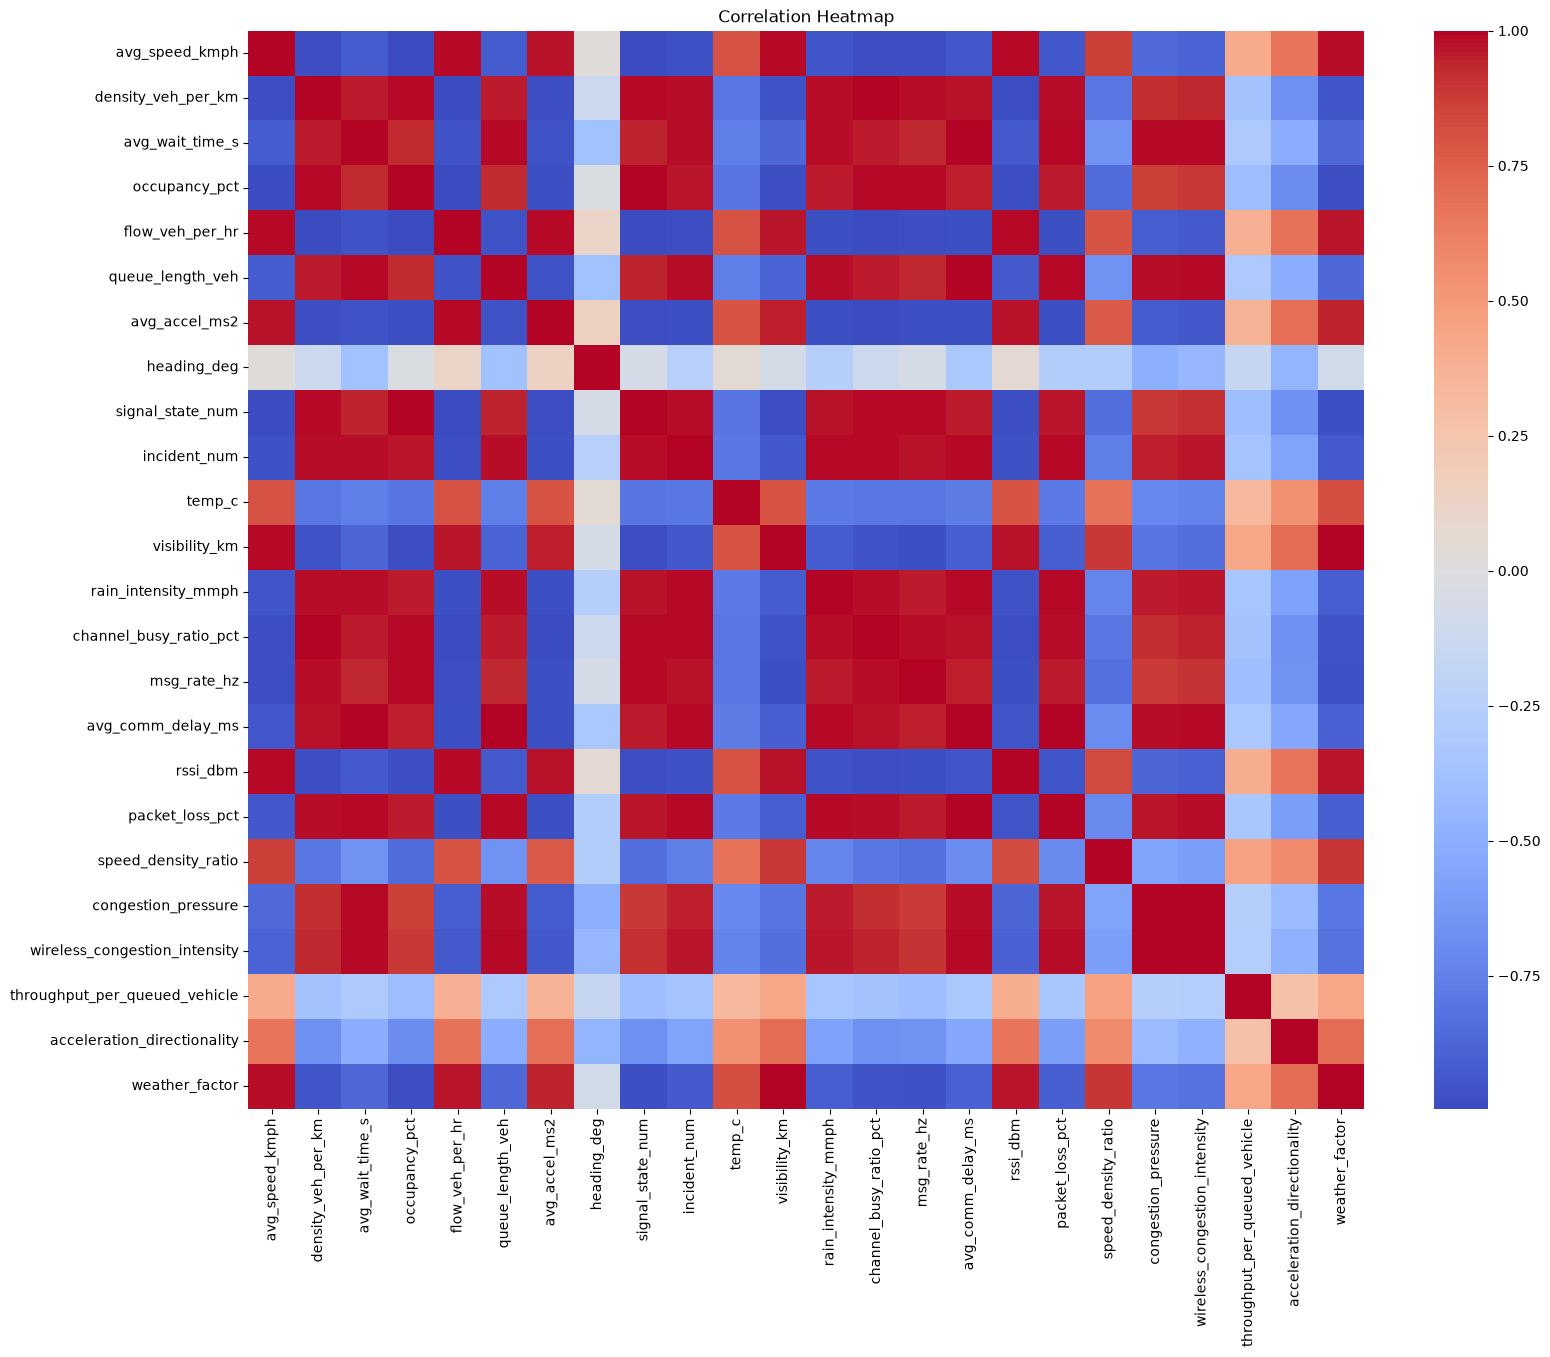

In [31]:
# Correlation Heatmap
numeric_features = df.select_dtypes(include=np.number).columns

corr_matrix = df[numeric_features].corr()

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Heatmap")

plt.show()

In [32]:
corr_matrix = df[numeric_features].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    (column, row, upper_triangle.loc[row, column])
    for column in upper_triangle.columns
    for row in upper_triangle.index
    if pd.notna(upper_triangle.loc[row, column])
    and upper_triangle.loc[row, column] > 0.85
]

high_corr[:20]

[('density_veh_per_km', 'avg_speed_kmph', np.float64(0.9804316980547365)),
 ('avg_wait_time_s', 'avg_speed_kmph', np.float64(0.9200663792063761)),
 ('avg_wait_time_s', 'density_veh_per_km', np.float64(0.9578471352041221)),
 ('occupancy_pct', 'avg_speed_kmph', np.float64(0.993253214430029)),
 ('occupancy_pct', 'density_veh_per_km', np.float64(0.984885287824476)),
 ('occupancy_pct', 'avg_wait_time_s', np.float64(0.9238703073987271)),
 ('flow_veh_per_hr', 'avg_speed_kmph', np.float64(0.9856977506468427)),
 ('flow_veh_per_hr', 'density_veh_per_km', np.float64(0.9942158997117169)),
 ('flow_veh_per_hr', 'avg_wait_time_s', np.float64(0.9580822450613758)),
 ('flow_veh_per_hr', 'occupancy_pct', np.float64(0.9896819832735778)),
 ('queue_length_veh', 'avg_speed_kmph', np.float64(0.9213500740791811)),
 ('queue_length_veh', 'density_veh_per_km', np.float64(0.957719417658063)),
 ('queue_length_veh', 'avg_wait_time_s', np.float64(0.9918280157049247)),
 ('queue_length_veh', 'occupancy_pct', np.float64

In [33]:
df['label'].value_counts()

label
Free-flow    57812
Moderate     54018
Heavy        47440
Gridlock     36444
Name: count, dtype: int64

<Axes: xlabel='label'>

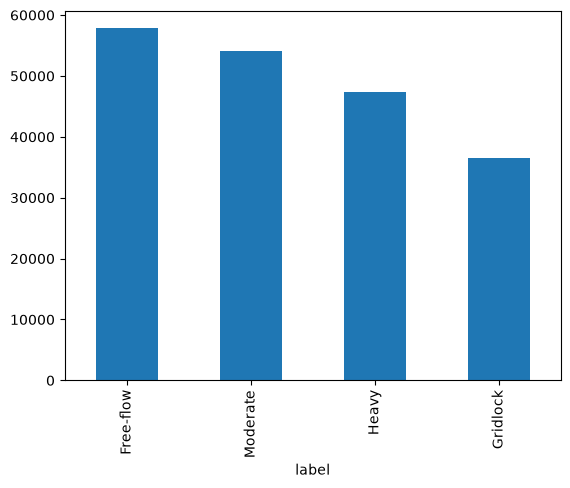

In [34]:
df['label'].value_counts().plot(kind='bar')

In [35]:
df['label'].value_counts(normalize=True)*100

label
Free-flow    29.539021
Moderate     27.600478
Heavy        24.239451
Gridlock     18.621049
Name: proportion, dtype: float64

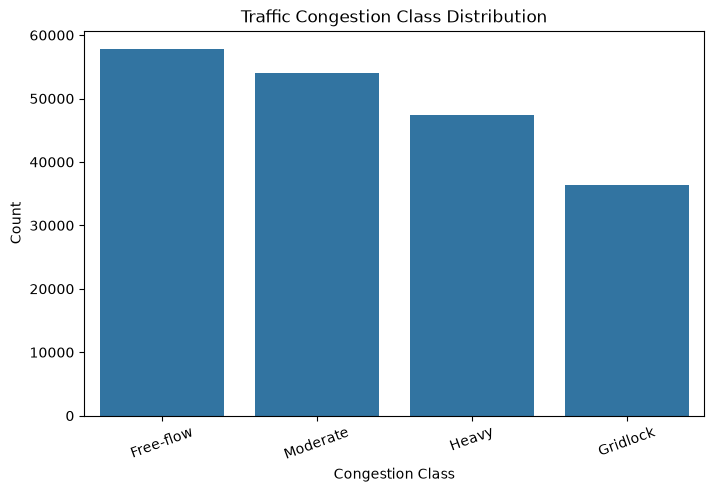

In [36]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='label',
    order=df['label'].value_counts().index
)

plt.title("Traffic Congestion Class Distribution")
plt.xlabel("Congestion Class")
plt.ylabel("Count")
plt.xticks(rotation=20)

plt.show()

In [37]:
important_features = [
    'avg_speed_kmph',
    'density_veh_per_km',
    'avg_wait_time_s',
    'occupancy_pct',
    'flow_veh_per_hr',
    'queue_length_veh'
]

class_summary = df.groupby('label')[important_features].mean()

print(class_summary)

           avg_speed_kmph  density_veh_per_km  avg_wait_time_s  occupancy_pct  \
label                                                                           
Free-flow       69.888407           10.083799         5.078360      10.142447   
Gridlock         5.135424           89.782377       119.507195      94.843695   
Heavy           24.959243           60.116191        50.403605      70.048455   
Moderate        45.155051           29.937430        19.998991      39.852813   

           flow_veh_per_hr  queue_length_veh  
label                                         
Free-flow      1997.699714          2.037336  
Gridlock        104.529045         59.760759  
Heavy           797.790920         25.199578  
Moderate       1501.549845          9.991342  


In [38]:
class_summary.round(2)

,avg_speed_kmph,density_veh_per_km,avg_wait_time_s,occupancy_pct,flow_veh_per_hr,queue_length_veh
label,,,,,,
Free-flow,69.89,10.08,5.08,10.14,1997.70,2.04
Gridlock,5.14,89.78,119.51,94.84,104.53,59.76
Heavy,24.96,60.12,50.40,70.05,797.79,25.20
Moderate,45.16,29.94,20.00,39.85,1501.55,9.99


In [39]:
# Timestamp
df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    errors='coerce'
)

In [40]:
df['timestamp'].head()

0   2025-09-29 04:54:49
1   2025-09-30 06:15:38
2   2025-09-29 05:46:06
3   2025-09-28 21:15:29
4   2025-09-28 00:29:20
Name: timestamp, dtype: datetime64[us]

In [41]:
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month

In [42]:
df[['timestamp','hour','day_of_week','month']].head()

,timestamp,hour,day_of_week,month
0,2025-09-29 04:54:49,4,0,9
1,2025-09-30 06:15:38,6,1,9
2,2025-09-29 05:46:06,5,0,9
3,2025-09-28 21:15:29,21,6,9
4,2025-09-28 00:29:20,0,6,9


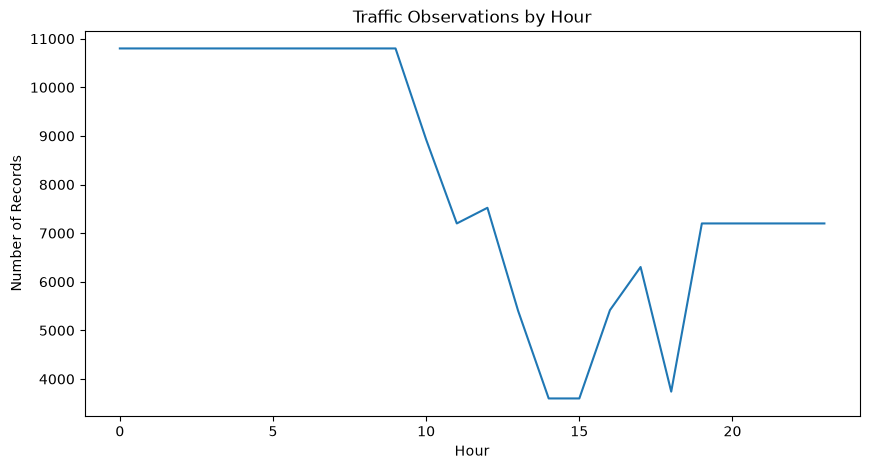

In [43]:
hourly_data = df.groupby('hour').size()

plt.figure(figsize=(10, 5))

hourly_data.plot()

plt.title("Traffic Observations by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Records")

plt.show()

In [44]:
# Road Segment Analysis
print("Unique road segments:")
print(df['road_segment_id'].nunique())


Unique road segments:
500


In [45]:
df['road_segment_id'].value_counts().head(20)

road_segment_id
S001    393
S003    393
S005    393
S006    393
S002    393
S004    393
S339    392
S357    392
S469    392
S308    392
S430    392
S018    392
S319    392
S025    392
S334    392
S444    392
S483    392
S307    392
S450    392
S314    392
Name: count, dtype: int64

In [46]:
segment_congestion = pd.crosstab(
    df['road_segment_id'],
    df['label'],
    normalize='index'
) * 100

print(segment_congestion.head())

label            Free-flow   Gridlock      Heavy   Moderate
road_segment_id                                            
S001             29.770992  18.829517  24.427481  26.972010
S002             29.516539  18.829517  24.427481  27.226463
S003             29.516539  19.083969  23.918575  27.480916
S004             29.770992  18.320611  24.681934  27.226463
S005             29.770992  18.829517  24.173028  27.226463


# Feature Engineering


In [47]:
# Speed Density Interaction
df['speed_density_interaction'] = (
    df['avg_speed_kmph'] *
    df['density_veh_per_km']
)


In [48]:
# Density vs Waiting Time
df['density_wait_interaction'] = (
    df['density_veh_per_km'] *
    df['avg_wait_time_s']
)

In [49]:
# Queue to flow ratio
df['queue_flow_ratio'] = (
    df['queue_length_veh'] /
    (df['flow_veh_per_hr'] + 1)
)

In [50]:
df[
    ['speed_density_interaction',
    'density_wait_interaction',
    'queue_flow_ratio'
    ]
].head()

,speed_density_interaction,density_wait_interaction,queue_flow_ratio
0,1074.9564,509.7246,0.005026
1,403.2450,10815.0309,0.524586
2,1345.2760,523.9155,0.007434
3,1337.7378,818.5121,0.006475
4,354.3580,41.6580,0.000895


In [51]:
drop_columns = [
    'label',
    'timestamp',
    'road_segment_id'
]

X = df.drop(columns=drop_columns)
y = df['label']

In [52]:
print("X shape:",X.shape)
print("y shape:",y.shape)

X shape: (195714, 30)
y shape: (195714,)


In [53]:
X.columns.tolist()

['avg_speed_kmph',
 'density_veh_per_km',
 'avg_wait_time_s',
 'occupancy_pct',
 'flow_veh_per_hr',
 'queue_length_veh',
 'avg_accel_ms2',
 'heading_deg',
 'signal_state_num',
 'incident_num',
 'temp_c',
 'visibility_km',
 'rain_intensity_mmph',
 'channel_busy_ratio_pct',
 'msg_rate_hz',
 'avg_comm_delay_ms',
 'rssi_dbm',
 'packet_loss_pct',
 'speed_density_ratio',
 'congestion_pressure',
 'wireless_congestion_intensity',
 'throughput_per_queued_vehicle',
 'acceleration_directionality',
 'weather_factor',
 'hour',
 'day_of_week',
 'month',
 'speed_density_interaction',
 'density_wait_interaction',
 'queue_flow_ratio']

In [54]:
X.isnull().sum().sort_values(ascending=False).head(10)

avg_speed_kmph        0
density_veh_per_km    0
avg_wait_time_s       0
occupancy_pct         0
flow_veh_per_hr       0
queue_length_veh      0
avg_accel_ms2         0
heading_deg           0
signal_state_num      0
incident_num          0
dtype: int64

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

import joblib

ModuleNotFoundError: No module named 'xgboost'

In [56]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [57]:
dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

{'Free-flow': np.int64(0),
 'Gridlock': np.int64(1),
 'Heavy': np.int64(2),
 'Moderate': np.int64(3)}

In [58]:
# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X,y_encoded,test_size=0.2,random_state=42)

In [59]:
print("Training data:",X_train.shape,y_train.shape)
print("Testing data:",X_test.shape,y_test.shape)

Training data: (156571, 30) (156571,)
Testing data: (39143, 30) (39143,)


# Scaling

In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
scaler.fit_transform(X_train)

array([[-0.81188093,  0.56095656,  0.22864035, ...,  0.46537174,
         0.02053638, -0.38606156],
       [ 0.25336107, -0.3111652 , -0.44729377, ...,  1.16654085,
        -0.54567411, -0.48119992],
       [ 0.12838619, -0.35378257, -0.62645996, ...,  0.82082073,
        -0.61322189, -0.48827267],
       ...,
       [-0.61808542,  0.57698069,  0.2844025 , ...,  1.10497145,
         0.06125187, -0.38807832],
       [ 0.1389415 , -0.54573118, -0.57724381, ...,  0.28677522,
        -0.62193788, -0.49313372],
       [-1.53850855,  1.5135399 ,  1.98975424, ..., -1.60077217,
         1.98076612,  3.07823074]], shape=(156571, 30))

In [62]:
scaler.transform(X_test)

array([[-0.53533178,  0.51288417,  0.14766403, ...,  1.25210435,
        -0.04638764, -0.39038112],
       [-0.63328506,  0.48629093,  0.41677697, ...,  0.90563691,
         0.10395327, -0.40959275],
       [ 0.25082779, -0.37730735, -0.58645668, ...,  0.96008637,
        -0.60280133, -0.49226638],
       ...,
       [-0.73461605,  0.68471739,  0.21554837, ...,  0.89583206,
         0.05881459, -0.39891972],
       [-0.65017356,  0.53777271,  0.27882628, ...,  0.93853659,
         0.04234314, -0.38367568],
       [ 1.33464714, -1.01247656, -0.89436068, ..., -0.2319213 ,
        -0.72600094, -0.51484962]], shape=(39143, 30))

# Logistic Regression

In [64]:
log_model = LogisticRegression(max_iter=1000,random_state=42)

log_model.fit(X_train_scaled,y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
    accuracy_score(y_test, y_pred_log))

Logistic Regression Accuracy: 0.9900876274174182


# Decision Tree

In [68]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train,y_train)
y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:",accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.9764197940883428


# Random Forest

In [69]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1)

rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:",
    accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9900876274174182


# XGBoost

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss')

xgb_model.fit(X_train,y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:",
    accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9900876274174182


## Model Comparsion

In [67]:
results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

print(results)

NameError: name 'y_pred_dt' is not defined

In [70]:
# Plot
plt.figure(figsize=(10, 5))

sns.barplot(
    data=results,
    x='Model',
    y='Accuracy'
)

plt.ylim(0, 1)

plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)

plt.show()

NameError: name 'results' is not defined

<Figure size 1000x500 with 0 Axes>

# Classification Report

In [ ]:
classification_report(y_test,y_pred_rf,target_names=label_encoder.classes_)

'              precision    recall  f1-score   support\n\n   Free-flow       0.99      0.99      0.99     11607\n    Gridlock       0.99      0.99      0.99      7267\n       Heavy       0.99      0.99      0.99      9372\n    Moderate       0.99      0.99      0.99     10897\n\n    accuracy                           0.99     39143\n   macro avg       0.99      0.99      0.99     39143\nweighted avg       0.99      0.99      0.99     39143\n'

## Confusion Matrix

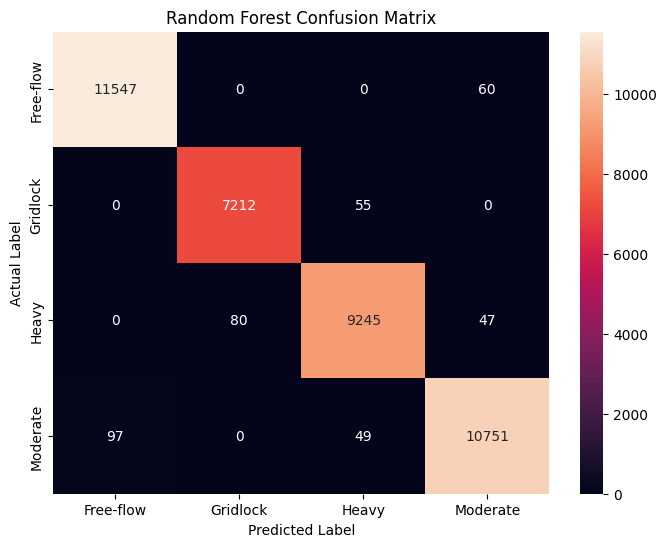

In [ ]:
cm = confusion_matrix(y_test,y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Random Forest Confusion Matrix")

plt.show()

In [ ]:
from sklearn.metrics import f1_score
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],
    'Weighted F1': [
        f1_score(y_test, y_pred_log, average='weighted'),
        f1_score(y_test, y_pred_dt, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_xgb, average='weighted')
    ]
})

print(model_results.sort_values(
    by='Weighted F1',
    ascending=False
))

                 Model  Accuracy  Weighted F1
0  Logistic Regression  0.990088     0.990084
2        Random Forest  0.990088     0.990084
3              XGBoost  0.990088     0.990084
1        Decision Tree  0.976445     0.976453


## Feature Importance

In [ ]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(
    ascending=False
)

print(feature_importance)

avg_speed_kmph                   0.072951
channel_busy_ratio_pct           0.071101
incident_num                     0.067680
flow_veh_per_hr                  0.066341
density_wait_interaction         0.064838
occupancy_pct                    0.064637
speed_density_ratio              0.062399
wireless_congestion_intensity    0.053447
congestion_pressure              0.051047
signal_state_num                 0.046840
avg_comm_delay_ms                0.046048
packet_loss_pct                  0.044184
weather_factor                   0.039045
density_veh_per_km               0.038662
queue_flow_ratio                 0.032222
rain_intensity_mmph              0.030226
avg_accel_ms2                    0.029548
throughput_per_queued_vehicle    0.029108
avg_wait_time_s                  0.024862
visibility_km                    0.021488
queue_length_veh                 0.013984
heading_deg                      0.010628
speed_density_interaction        0.010544
msg_rate_hz                      0

In [ ]:
top_features = feature_importance.head(10)
top_features

,0
avg_speed_kmph,0.072951
channel_busy_ratio_pct,0.071101
incident_num,0.067680
flow_veh_per_hr,0.066341
density_wait_interaction,0.064838
occupancy_pct,0.064637
speed_density_ratio,0.062399
wireless_congestion_intensity,0.053447
congestion_pressure,0.051047
signal_state_num,0.046840


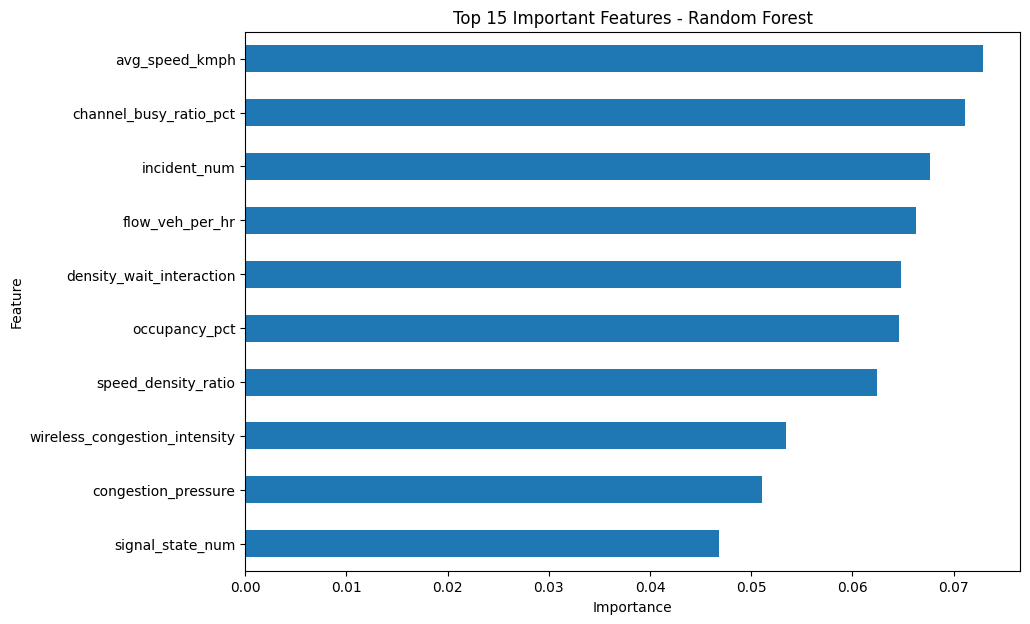

In [ ]:
plt.figure(figsize=(10, 7))

top_features.sort_values().plot(
    kind='barh')

plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

# Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score


In [ ]:
y_train_series = pd.Series(
    y_train,
    index=X_train.index)

X_cv = X_train.sample(
    n=15000,
    random_state=42)

y_cv = y_train_series.loc[X_cv.index]

rf_cv_model = RandomForestClassifier(
    n_estimators=50,
    random_state=42,
    n_jobs=-1)

# 3-fold cross validation
cv_scores = cross_val_score(
    rf_cv_model,
    X_cv,
    y_cv,
    cv=3,
    scoring='f1_weighted',
    n_jobs=-1
)

print("CV Scores:", cv_scores)
print("Mean CV F1 Score:", cv_scores.mean())

## Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
# Fast parameter options
param_dist = {
    'n_estimators': [50, 75, 100],
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=5,              # only 5 combinations
    cv=2,                  # only 2 folds
    scoring='f1_weighted',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_cv, y_cv)

print("Best Parameters:")
print(random_search.best_params_)

print("Best CV F1 Score:")
print(random_search.best_score_)

Fitting 2 folds for each of 5 candidates, totalling 10 fits
Best Parameters:
{'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}
Best CV F1 Score:
0.9889593621031276


In [ ]:
best_rf = random_search.best_estimator_

print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 50, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}


In [ ]:
y_pred_best = best_rf.predict(X_test)

print("Prediction completed!")

Prediction completed!


In [ ]:
from sklearn.metrics import accuracy_score

final_accuracy = accuracy_score(
    y_test,
    y_pred_best)

print("Final Test Accuracy:", final_accuracy)

Final Test Accuracy: 0.9900876274174182


In [ ]:
import joblib
joblib.dump(best_rf,"best_model.pkl")

joblib.dump(label_encoder,"label_encoder.pkl")

joblib.dump(X.columns.tolist(),"feature_names.pkl")

print("Model files saved successfully!")

Model files saved successfully!


In [ ]:
loaded_model = joblib.load("best_model.pkl")
loaded_encoder = joblib.load("feature_names.pkl")

In [ ]:
sample = X_test.iloc[[0]]

In [ ]:
prediction = loaded_model.predict(sample)
predicted_class = loaded_encoder[prediction[0]]

print("Predicted Traffic Condition:", predicted_class)

Predicted Traffic Condition: avg_wait_time_s


In [ ]:
deployment_features = [
    'avg_speed_kmph',
    'density_veh_per_km',
    'avg_wait_time_s',
    'occupancy_pct',
    'flow_veh_per_hr',
    'queue_length_veh',
    'avg_accel_ms2',
    'signal_state_num',
    'incident_num',
    'temp_c',
    'visibility_km',
    'rain_intensity_mmph'
]

In [6]:
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

deployment_features = [
    'avg_speed_kmph',
    'density_veh_per_km',
    'avg_wait_time_s',
    'occupancy_pct',
    'flow_veh_per_hr',
    'queue_length_veh',
    'avg_accel_ms2',
    'signal_state_num',
    'incident_num',
    'temp_c',
    'visibility_km',
    'rain_intensity_mmph'
]

X_deploy = df[deployment_features]
y_deploy = df['label']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_deploy,
    y_deploy,
    test_size=0.20,
    random_state=42,
    stratify=y_deploy
)

deploy_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

deploy_model.fit(X_train_d, y_train_d)

joblib.dump(
    deploy_model,
    r"C:\Users\E\OneDrive\Desktop\TrafficCongestion\deploy_model.pkl"
)

print("MODEL SAVED SUCCESSFULLY")

MODEL SAVED SUCCESSFULLY
